# Requirements and installs

In [1]:
%%capture
pip install --upgrade pip

In [2]:
%%capture
pip install xgboost lightgbm catboost

In [3]:
import typing as t
import numpy as np
import pandas as pd
from dataclasses import dataclass
from zoneinfo import ZoneInfo
import unicodedata, re

# Utils básicos
def _pip_install(pkg):
    try:
        __import__(pkg.split("==")[0].replace("-", "_"))
    except ImportError:
        import subprocess, sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

for pkg in ["holidays"]:
    _pip_install(pkg)

import holidays
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss
from sklearn.calibration import IsotonicRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils import Bunch
from sklearn.utils.class_weight import compute_sample_weight

RNG_SEED = 42
np.random.seed(RNG_SEED)

# Config

In [4]:
from google.cloud import bigquery
client = bigquery.Client(project="spin-aip-singularity-comp-sb")

query = """
SELECT * 
FROM `spin-aip-singularity-comp-sb.model_activation.dataste_model_activation_long_timewindow_V-1-4-1` 
"""
data = client.query(query).to_dataframe()

In [16]:
@dataclass
class Config:
    project_id: str = "spin-aip-singularity-comp-sb"
    table_fqn: str = "spin-aip-singularity-comp-sb.model_activation.dataste_model_activation_timewindow_reduction_V-1-4-1"
    label_col: str = "label_activated_30d"
    signup_ts_col: str = "signup_ts"
    signup_date_col: str = "signup_date"
    tz_local: str = "America/Mexico_City"
    embargo_days: int = 3      # <- usado por Activation30Model._purged_tss_indices
    holdout_days: int = 14 
    n_splits: int = 5
    train_sample_frac: float = 1.0
    random_state: int = RNG_SEED
    lift_fracs: t.Tuple[float, ...] = (0.01, 0.02, 0.05, 0.10)

CFG = Config()

# Leakage / IDs a ignorar en features
LEAKY_ALWAYS = {
    # labels y derivados
    "y_w0","y_w1","y_w7","y_w30","y_cum30","label_activated_30d","label_5tx_30d",
    # info post-activación / post-window
    "activation_date_ever","activation_date_30d","days_to_first_activation",
    "tx_30d_count","tx_30d_amount","tx_30d_from_activation", "first_tx_type","first_tx_amount","latest_tx_date",
    # confirmaciones si no son estrictamente previas al cutoff de cada horizonte "phn_confir","email_confir",
    "phn_confir_d7","email_confir_d7","both_confir_d7",'Card_linked_date',"activation_*","*_30d_*","*latest_tx*",
    #ID
    "user_id", "userid","channelUserIdentifier", "premia_accountid", "accountid", "member_id", "spin_user_id", "id"
}

LEAK_BAN = {
    "y_w0","y_w1","y_w7","y_w30","y_cum30","label_activated_30d","label_5tx_30d",
    "activation_date_ever","activation_date_30d","days_to_first_activation",
    "latest_tx_date","tx_30d_count","tx_30d_amount","tx_30d_from_activation",
    "first_tx_type","first_tx_amount","activation_channel"
}

# Regex anti-leak (además del set LEAKY_ALWAYS existente)
LEAK_PATTERNS = [
    r"(^|_)activation(_|$)", r"(^|_)first_tx(_|$)", r"(^|_)latest_tx(_|$)",
    r"(^|_)tx_30d(_|$)", r"(^|_)days_to_first(_|$)", r"(^|_)from_activation(_|$)"
]
def assert_no_regex_leak(df_like: pd.DataFrame):
    bad = []
    for c in df_like.columns:
        for pat in LEAK_PATTERNS:
            if re.search(pat, c, flags=re.IGNORECASE):
                bad.append(c); break
    assert len(bad) == 0, f"LEAKAGE by regex: quita columnas {sorted(set(bad))}"
def assert_no_labelish_cols(df_like):
    inter = [c for c in df_like.columns if c in LEAK_BAN]
    assert len(inter) == 0, f"LEAKAGE: quita columnas {inter}"


EXTRA_DROP_TS = {"phone_conf_ts", "email_conf_ts"}

# Normalización de estados (stateName -> siglas)
def _norm(s: str) -> str:
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    s = re.sub(r"[^A-Z ]", "", s.upper())
    return re.sub(r"\s+", " ", s).strip()

STATE_TO_ABBR = {
    "AGUASCALIENTES":"AG","BAJA CALIFORNIA":"BC","BAJA CALIFORNIA SUR":"BS","CAMPECHE":"CM",
    "CHIAPAS":"CS","CHIHUAHUA":"CH","CIUDAD DE MEXICO":"DF","COAHUILA":"CO","COLIMA":"CL",
    "DURANGO":"DG","GUANAJUATO":"GT","GUERRERO":"GR","HIDALGO":"HG","JALISCO":"JA","MEXICO":"EM",
    "MICHOACAN":"MI","MORELOS":"MO","NAYARIT":"NA","NUEVO LEON":"NL","OAXACA":"OA","PUEBLA":"PU",
    "QUERETARO":"QT","QUINTANA ROO":"QR","SAN LUIS POTOSI":"SL","SINALOA":"SI","SONORA":"SO",
    "TABASCO":"TB","TAMAULIPAS":"TM","TLAXCALA":"TL","VERACRUZ":"VE","YUCATAN":"YU","ZACATECAS":"ZA"
}
STATE_SYNONYMS = {"CDMX":"CIUDAD DE MEXICO","ESTADO DE MEXICO":"MEXICO","EDOMEX":"MEXICO"}

# birthState canon + buckets regionales
CANON = {
    "SR":"SO","SO":"SO","VZ":"VE","VE":"VE","YN":"YU","YU":"YU","JC":"JA","JA":"JA","MC":"MI","MI":"MI",
    "TS":"TM","TM":"TM","TC":"TB","TB":"TB","CC":"CL","CL":"CL","DF":"DF","EM":"EM","NL":"NL","BC":"BC",
    "BS":"BS","SI":"SI","NA":"NA","DG":"DG","ZA":"ZA","AG":"AG","SL":"SL","HG":"HG","MO":"MO","TL":"TL",
    "PU":"PU","QT":"QT","GT":"GT","OA":"OA","CM":"CM","CS":"CS","CO":"CO","GR":"GR","QR":"QR","CH":"CH",
    "MS":"MI","MN":"MI","SP":"SL","NE":"NL","OC":"OA","PL":"PU","NT":"NA","ZS":"ZA","AS":"AG","UN":"OT", None:"OT"
}
REGION_BUCKET = {
    "BC":1,"SO":1,"CH":1,"CO":1,"NL":1,"TM":1,                # Norte
    "BS":2,"SI":2,"NA":2,"DG":2,"ZA":2,                       # Norte-Occidente
    "JA":3,"AG":3,"CL":3,"MI":3,"SL":3,                       # Centro-Norte
    "DF":4,"EM":4,"HG":4,"MO":4,"TL":4,"PU":4,"QT":4,"GT":4,  # Centro-País
    "CS":5,"TB":5,"CM":5,"YU":5,"QR":5,"OA":5,"GR":5,"VE":5,  # Sur-Sureste
    "OT":0
}

# Mapeos categóricos
GENDER_MAP = {"female":1, "male":0}
USER_TYPE_MAP = {"HYBRID":0, "DIGITAL":1, "ANALOG":2}
CHANNEL_DETAIL_MAP = {"ORGANIC":0,"COLLABORATOR":1,"POS":2,"SPIN_PREMIA":3,"DIGITAL_ORGANIC":4,"DIGITAL":5}

PHYSICAL_TX = {
    "CASH_IN_AT_OXXO","CASH_IN_AT_OXXO_QR","CASH_OUT_WITH_CARD_AT_OXXO",
    "CASH_OUT_AT_OXXO","CASH_OUT_AT_MERCHANT","CARD_PURCHASE","CARD_ATM_WITHDRAWAL"
}
DIGITAL_TX = {
    "SPEI_CASH_IN","P2P_TRANSFER_TARGET_CLABE","P2P_TRANSFER_TARGET",
    "P2P_TRANSFER_TARGET_CARD","P2P_TRANSFER_SOURCE_CARD","P2P_TRANSFER_SOURCE_CLABE",
    "P2P_TRANSFER_SOURCE","TRANSFER_TO_CARD","TRANSFER_TO_CLABE",
    "IN_APP_PURCHASE_TAE","IN_APP_PURCHASE_BILLPAYMENT","QR_MERCHANT_PAYMENT",
    "GIFT_CARD_PURCHASE","INTERNATIONAL_REMITTANCE_CASH_IN"
}
TX_TRINARY_MAP = {**{k:0 for k in PHYSICAL_TX}, **{k:1 for k in DIGITAL_TX}, **{None:2}}
TX_TRINARY_NAME = {0:"FISICAS", 1:"DIGITALES", 2:"OTRAS"}


# FeatureBuilder

In [17]:
class FeatureBuilder:
    def __init__(self, cfg: Config):
        self.cfg = cfg
        self.ohe_states_: t.List[str] = []

    @staticmethod
    def _state_to_abbr(s: t.Any) -> str:
        if pd.isna(s): return "OT"
        s = str(s)
        if s.upper() in REGION_BUCKET: return s.upper()
        s2 = _norm(s)
        s2 = STATE_SYNONYMS.get(s2, s2)
        return STATE_TO_ABBR.get(s2, "OT")

    @staticmethod
    def _canon_birthstate(s: t.Any) -> str:
        if pd.isna(s): return "OT"
        s = str(s).upper()
        return CANON.get(s, s if s in REGION_BUCKET else "OT")

    def _mk_time_feats(self, df: pd.DataFrame) -> pd.DataFrame:
        ts = pd.to_datetime(df[self.cfg.signup_ts_col], utc=True).dt.tz_convert(ZoneInfo(self.cfg.tz_local))
        df = df.copy()
        df["signup_dow"] = ts.dt.weekday.astype("int16")
        df["signup_week"] = ts.dt.isocalendar().week.astype("int16")
        df["signup_month"] = ts.dt.month.astype("int16")
        hr = ts.dt.hour
        df["signup_daypart"] = np.select([(hr>=5)&(hr<=11),(hr>=12)&(hr<=17)],[0,1],default=2).astype("int8")
        years = list({d.year for d in pd.to_datetime(df[self.cfg.signup_date_col]).dt.date})
        mx_hol = holidays.MX(years=years)
        dates = pd.to_datetime(df[self.cfg.signup_date_col]).dt.date
        df["is_holiday_mx"] = dates.map(lambda d: 1 if d in mx_hol else 0).astype("int8")
        day = ts.dt.day
        eom = (ts + pd.offsets.MonthEnd(0)).dt.day
        df["near_payday_any"] = ((np.abs(day-1)<=3)|(np.abs(day-15)<=3)|(np.abs(day-eom)<=3)).astype("int8")
        df["near_payday_1st"] = (np.abs(day-1)<=3).astype("int8")
        df["near_payday_15"]  = (np.abs(day-15)<=3).astype("int8")
        df["near_payday_eom"] = (np.abs(day-eom)<=3).astype("int8")
        return df

    def fit(self, df: pd.DataFrame):
        st = df["stateName"].map(self._state_to_abbr)
        self.ohe_states_ = sorted(st.dropna().unique().tolist())
        if "OT" not in self.ohe_states_: self.ohe_states_.append("OT")
        return self

    def transform(self, df: pd.DataFrame) -> Bunch:
        df = df.copy()
        s_ts = pd.to_datetime(df[CFG.signup_ts_col], utc=True)

        # Categóricas core
        df["gender_bin"] = df["gender"].map(GENDER_MAP).astype("float32")
        df["user_type_tri"] = df["user_type"].map(USER_TYPE_MAP).astype("float32")
        df["channel_detail_code"] = df["channelDetail"].map(CHANNEL_DETAIL_MAP).astype("float32")

        # birth bucket + edad
        bcanon = df["birthState"].map(self._canon_birthstate)
        df["birth_bucket"] = bcanon.map(REGION_BUCKET).astype("float32")
        bdate = pd.to_datetime(df["birth_date"], errors="coerce", utc=True)
        df["age_years"] = ((s_ts - bdate).dt.days/365.25).astype("float32")

        # Time features
        df = self._mk_time_feats(df)

        # state OHE
        st = df["stateName"].map(self._state_to_abbr)
        for ab in self.ohe_states_:
            df[f"state_{ab}"] = (st==ab).astype("int8")

        # Confirmaciones / flags: Int nulos a 0
        if "phone_conf_ts" in df.columns:
            phn_ts = pd.to_datetime(df["phone_conf_ts"], errors="coerce", utc=True)
            df["phn_confir"] = (phn_ts < s_ts).fillna(False).astype("int8")
        else:
            df["phn_confir"] = 0

        if "email_conf_ts" in df.columns:
            email_ts = pd.to_datetime(df["email_conf_ts"], errors="coerce", utc=True)
            df["email_confir"] = (email_ts < s_ts).fillna(False).astype("int8")
        else:
            df["email_confir"] = 0

        # Card_linked_date -> deltas sin fuga
        if "Card_linked_date" in df.columns:
            card_dt = pd.to_datetime(df["Card_linked_date"], errors="coerce", utc=True)
            # Cambiar <= por < (estrictamente antes)
            before = card_dt < s_ts  
            lag_days = (s_ts - card_dt).dt.days.astype("float32")
            df["card_linked_before_signup"] = before.fillna(False).astype("int8")
            # Solo crear lag_days si ocurrió ANTES (no <=)
            df["card_linked_lag_days"] = np.where(before, lag_days, np.nan).astype("float32")
            df = df.drop(columns=["Card_linked_date"])

        LEAKY_FEATURES = {
            'lifespan_days',        #  LEAKAGE CONFIRMADO (corr=0.535)
            'days_since_last',      #  Sospechoso (corr=0.329)
        }

            
        # Armar X
        drop_cols = set(LEAKY_ALWAYS) | {
            "stateName","gender","user_type","channelDetail","birthState","birth_date",
            CFG.signup_date_col, CFG.signup_ts_col
        } | set(EXTRA_DROP_TS) | LEAKY_FEATURES  # ← MODIFICAR ESTA LÍNEA

        drop_cols = [c for c in drop_cols if c in df.columns]
        X = df.drop(columns=drop_cols, errors="ignore")

        # Limpiar tipos
        # 1) Si queda algún dtype extension de BigQuery -> fuera
        bad_ext = [c for c in X.columns if "db_dtypes" in str(X[c].dtype).lower() or "dbdate" in str(X[c].dtype).lower()]
        X = X.drop(columns=bad_ext, errors="ignore")

        # 2) Casts seguros
        for c in X.columns:
            if pd.api.types.is_integer_dtype(X[c]) or str(X[c].dtype).startswith("Int"):
                X[c] = pd.to_numeric(X[c], errors="coerce").fillna(0).astype("float32")
            elif pd.api.types.is_float_dtype(X[c]):
                X[c] = X[c].astype("float32")
            elif pd.api.types.is_bool_dtype(X[c]):
                X[c] = X[c].astype("int8")
            elif pd.api.types.is_datetime64_any_dtype(X[c]):
                X = X.drop(columns=[c])

        # 3) Objetos -> fuera
        obj_cols = X.select_dtypes(include=["object"]).columns.tolist()
        if obj_cols:
            X = X.drop(columns=obj_cols)

        # y binaria
        y = pd.to_numeric(df[CFG.label_col], errors="coerce").fillna(0).astype(int).values
        
        assert_no_regex_leak(X)
        LEAK_BAN = LEAKY_ALWAYS | {"first_tx_type", "first_tx_amount"}
        assert_no_labelish_cols(X)
        
        meta = pd.DataFrame({
            "user_id": df.get("user_id", pd.Series(index=df.index, dtype="object")),
            "signup_date": pd.to_datetime(df[CFG.signup_date_col], errors="coerce"),
            "gender": df["gender"].astype(str),
            "channelDetail": df["channelDetail"].astype(str),
            "state_abbr": st.astype(str)
        })
        return Bunch(X=X, y=y, meta=meta)

# Modelo W30

In [19]:
def lift_at_k(y_true, y_score, frac: float) -> float:
    n = len(y_true); k = max(1, int(n*frac))
    idx = np.argpartition(-y_score, k-1)[:k]
    top_pos = y_true[idx].sum()
    base_rate = y_true.mean()
    expected_pos = k*base_rate
    return float(top_pos/expected_pos) if expected_pos>0 else np.nan

class Activation30Model:
    def __init__(self, cfg: Config):
        self.cfg = cfg
        self.model_folds_: t.List[HistGradientBoostingClassifier] = []
        self.iso_folds_: t.List[IsotonicRegression] = []
        self.metrics_ = {}
        self.oof_pred_ = None
        self.feature_names_: t.List[str] = []

    def _make_model(self):
        return HistGradientBoostingClassifier(
                learning_rate=0.5,        
                max_leaf_nodes=15,        
                min_samples_leaf=200,      
                l2_regularization=5.0,   
                early_stopping=True,     
                validation_fraction=0.15, 
                n_iter_no_change=20,  
                random_state=self.cfg.random_state
        )
    def _apply_embargo(self, train_idx: np.ndarray, val_idx: np.ndarray, 
                       time_order: np.ndarray) -> t.Tuple[np.ndarray, np.ndarray]:
        """Purga registros del train/val que violen el embargo temporal"""
        if self.cfg.embargo_days == 0:
            return train_idx, val_idx

        # Convertir a pandas Timestamp para operaciones seguras
        train_dates = pd.to_datetime(time_order[train_idx])
        val_dates = pd.to_datetime(time_order[val_idx])

        # Última fecha de train
        last_train_date = train_dates.max()

        # Calcular embargo cutoff
        embargo_cutoff = last_train_date + pd.Timedelta(days=self.cfg.embargo_days)

        # Filtrar validación
        val_valid_mask = val_dates >= embargo_cutoff
        val_filtered = val_idx[val_valid_mask]

        # VALIDACIÓN CRÍTICA: Asegurar mínimo de muestras
        min_samples = 100  # mínimo razonable para HistGradientBoosting
        if len(val_filtered) < min_samples:
            print(f"WARNING: Embargo dejó {len(val_filtered)} muestras (< {min_samples}). "
                  f"Usando fold completo sin embargo.")
            return train_idx, val_idx

        removed = len(val_idx) - len(val_filtered)
        print(f" Embargo aplicado: {removed} muestras removidas de validación "
              f"({removed/len(val_idx)*100:.1f}%)")

        return train_idx, val_filtered

    def fit_cv(self, X: pd.DataFrame, y: np.ndarray, time_order: np.ndarray):
        # ordenar temporal
        order = np.argsort(time_order)
        X = X.iloc[order].reset_index(drop=True)
        y = y[order]

        tss = TimeSeriesSplit(n_splits=self.cfg.n_splits)
        oof = np.zeros(len(X), dtype=float)
        self.model_folds_.clear(); self.iso_folds_.clear()
        self.feature_names_ = X.columns.tolist()

        for f,(tr,va) in enumerate(tss.split(X)):
            tr, va = self._apply_embargo(tr, va, time_order)
            Xtr, Xva = X.iloc[tr], X.iloc[va]
            ytr, yva = y[tr], y[va]

            # class weight via sample_weight
            sw = compute_sample_weight(class_weight="balanced", y=ytr).astype("float32")


            m = self._make_model()
            m.fit(Xtr, ytr, sample_weight=sw)

            p_raw = m.predict_proba(Xva)[:,1]
            iso = IsotonicRegression(out_of_bounds="clip").fit(p_raw, yva)
            p_cal = iso.transform(p_raw)
            oof[va] = p_cal

            self.model_folds_.append(m); self.iso_folds_.append(iso)
            print(f"[Fold {f+1}] AP={average_precision_score(yva,p_cal):.4f} | "
                  f"AUC={roc_auc_score(yva,p_cal):.4f} | "
                  f"Brier={brier_score_loss(yva,p_cal):.4f}")

        self.oof_pred_ = oof
        self.metrics_ = {
            "OOF_AP": average_precision_score(y, oof),
            "OOF_AUC": roc_auc_score(y, oof),
            "OOF_Brier": brier_score_loss(y, oof),
            **{f"OOF_Lift@{int(fr*100)}%": lift_at_k(y,oof,fr) for fr in self.cfg.lift_fracs}
        }
        return self

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        preds = np.zeros(len(X), dtype=float)
        for m, iso in zip(self.model_folds_, self.iso_folds_):
            preds += iso.transform(m.predict_proba(X)[:,1])
        return preds / max(1, len(self.model_folds_))

# Model type of transaction

In [20]:
class TxTypeModel:
    def __init__(self, cfg: Config):
        self.cfg = cfg
        self.model_: HistGradientBoostingClassifier | None = None
        self.classes_: np.ndarray | None = None

    def _make_model(self):
        return HistGradientBoostingClassifier(
                learning_rate=0.5,        
                max_leaf_nodes=15,        
                min_samples_leaf=200,      
                l2_regularization=5.0,    
                early_stopping=True,      
                validation_fraction=0.15, 
                n_iter_no_change=20,  
                random_state=self.cfg.random_state
        )

    def fit(self, X: pd.DataFrame, y_tx: np.ndarray):
        # Pesos por clase inversos a la frecuencia
        classes, counts = np.unique(y_tx, return_counts=True)
        inv_freq = {c: (counts.sum()/ (len(classes)*cnt)) for c, cnt in zip(classes, counts)}
        sw = np.array([inv_freq[v] for v in y_tx], dtype="float32")

        m = self._make_model()
        m.fit(X, y_tx, sample_weight=sw)
        self.model_ = m
        self.classes_ = classes
        return self

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        assert self.model_ is not None
        proba = self.model_.predict_proba(X)
        # asegurar columnas en orden [0,1,2]
        out = np.zeros((len(X), 3), dtype=float)
        for i, c in enumerate(self.classes_):
            out[:, int(c)] = proba[:, i]
        return out

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        return np.argmax(self.predict_proba(X), axis=1)

# Data Load, build Features, training

In [21]:
# 4.1 Carga
try:
    from google.cloud import bigquery
    client = bigquery.Client(project=CFG.project_id)
    data_raw = client.query(f"SELECT * FROM `{CFG.table_fqn}`").to_dataframe()
    print("Data shape:", data_raw.shape)
except Exception as e:
    print("[WARN] BigQuery no disponible aquí. Asumiendo que 'data_raw' ya existe en el entorno.")
    data_raw = data  # fallback si ya existe

# 4.2 Separar holdout ANTES de feature engineering
max_signup = pd.to_datetime(data_raw[CFG.signup_date_col]).max()
holdout_cutoff = max_signup - pd.Timedelta(days=CFG.holdout_days)

mask_train = pd.to_datetime(data_raw[CFG.signup_date_col]) < holdout_cutoff
data_train = data_raw[mask_train].copy()
data_holdout = data_raw[~mask_train].copy()

print(f"Train shape: {data_train.shape} | Holdout shape: {data_holdout.shape}")

# 4.3 Feature engineering EN TRAIN
fb = FeatureBuilder(CFG).fit(data_train)
fe_train = fb.transform(data_train)
X_train, y_train, meta_train = fe_train.X, fe_train.y, fe_train.meta

# 4.4 Modelo W30 (binario) - SOLO EN TRAIN
time_order = pd.to_datetime(data_train[CFG.signup_date_col], errors="coerce").values
m_w30 = Activation30Model(CFG).fit_cv(X_train, y_train, time_order)
print("\n=== METRICAS TRAIN (OOF) ===")
print(m_w30.metrics_)

# 4.5 Evaluar en HOLDOUT (simula producción)
fe_holdout = fb.transform(data_holdout)
X_holdout, y_holdout, meta_holdout = fe_holdout.X, fe_holdout.y, fe_holdout.meta
score_holdout = m_w30.predict_proba(X_holdout)

holdout_metrics = {
    "Holdout_AP": average_precision_score(y_holdout, score_holdout),
    "Holdout_AUC": roc_auc_score(y_holdout, score_holdout),
    "Holdout_Brier": brier_score_loss(y_holdout, score_holdout),
    **{f"Holdout_Lift@{int(fr*100)}%": lift_at_k(y_holdout, score_holdout, fr) 
       for fr in CFG.lift_fracs}
}
print("\n=== METRICAS HOLDOUT (Producción simulada) ===")
print(holdout_metrics)

# 4.6 Etiqueta multiclase para "tipo de transacción" - SOLO EN TRAIN activados
ft = data_train["first_tx_type"].astype(object)
y_tx_raw = ft.where(data_train[CFG.label_col]==1, np.nan)
y_tx_tri = y_tx_raw.map(lambda v: TX_TRINARY_MAP.get(v, 
    (0 if isinstance(v,str) and v in PHYSICAL_TX else 
     (1 if isinstance(v,str) and v in DIGITAL_TX else np.nan))))
mask_train_tx = y_tx_tri.notna()
X_tx_train = X_train.loc[mask_train_tx].reset_index(drop=True)
y_tx_train = y_tx_tri.loc[mask_train_tx].astype(int).values

# 4.7 Train multiclase
m_tx = TxTypeModel(CFG).fit(X_tx_train, y_tx_train)

# 4.8 Predecir para TRAIN + HOLDOUT combinados
X_all = pd.concat([X_train, X_holdout], axis=0, ignore_index=True)
meta_all = pd.concat([meta_train, meta_holdout], axis=0, ignore_index=True)
y_all = np.concatenate([y_train, y_holdout])

score_w30_all = m_w30.predict_proba(X_all)
proba_tx_all = m_tx.predict_proba(X_all)
tx_reco_all = np.argmax(proba_tx_all, axis=1)

# 4.9 Armar DF final con dimensiones correctas
preds_w30_tx = pd.DataFrame({
    "user_id": meta_all["user_id"].values,
    "signup_date": meta_all["signup_date"].values,
    "score_w30": score_w30_all,
    "tx_type_reco": tx_reco_all,
    "tx_type_reco_name": pd.Series(tx_reco_all).map(TX_TRINARY_NAME).values,
    "proba_tx_phys": proba_tx_all[:,0],
    "proba_tx_digital": proba_tx_all[:,1],
    "proba_tx_otras": proba_tx_all[:,2],
    "is_holdout": np.concatenate([
        np.zeros(len(X_train), dtype=bool), 
        np.ones(len(X_holdout), dtype=bool)
    ])
})

# Orden sugerido: top propensity primero
preds_w30_tx = preds_w30_tx.sort_values("score_w30", ascending=False).reset_index(drop=True)

print("\n=== Preview (Top 20) ===")
display(preds_w30_tx.head(20))

Data shape: (2426355, 37)
Train shape: (2300923, 37) | Holdout shape: (125432, 37)
[Fold 1] AP=0.8047 | AUC=0.7633 | Brier=0.1855
[Fold 2] AP=0.8061 | AUC=0.7623 | Brier=0.1864
[Fold 3] AP=0.8078 | AUC=0.7672 | Brier=0.1851
[Fold 4] AP=0.8149 | AUC=0.7721 | Brier=0.1827
[Fold 5] AP=0.8178 | AUC=0.7780 | Brier=0.1800

=== METRICAS TRAIN (OOF) ===
{'OOF_AP': 0.7788645480133756, 'OOF_AUC': 0.6815359826314744, 'OOF_Brier': 0.2586549954999337, 'OOF_Lift@1%': 1.496522213383362, 'OOF_Lift@2%': 1.4795885901146615, 'OOF_Lift@5%': 1.4468753840253763, 'OOF_Lift@10%': 1.4097065807912998}

=== METRICAS HOLDOUT (Producción simulada) ===
{'Holdout_AP': 0.6973400437475925, 'Holdout_AUC': 0.7345645631316746, 'Holdout_Brier': 0.21209429709677818, 'Holdout_Lift@1%': 1.6163683399037543, 'Holdout_Lift@2%': 1.5837546086360113, 'Holdout_Lift@5%': 1.5098544972426122, 'Holdout_Lift@10%': 1.48730760470876}

=== Preview (Top 20) ===


,user_id,signup_date,score_w30,tx_type_reco,tx_type_reco_name,proba_tx_phys,proba_tx_digital,proba_tx_otras,is_holdout
0,1a63ee6a-2eda-44a6-b42e-e3f0b3d8d346,2025-03-15,1.000000,1,DIGITALES,0.423826,0.576174,0.0,False
1,6885afa5-6d80-408c-8dda-45feec67d0f1,2025-01-15,1.000000,1,DIGITALES,0.361830,0.638170,0.0,False
2,ad6bdd2e-d4e3-4474-bccf-0dd8ffe12c7f,2025-01-28,1.000000,1,DIGITALES,0.414143,0.585857,0.0,False
3,d4c4ec58-8149-48d2-b8f4-16111f9c0026,2025-02-11,1.000000,1,DIGITALES,0.308224,0.691776,0.0,False
4,0bd9571b-bf5b-4c28-b188-ba688a87294c,2025-01-15,1.000000,1,DIGITALES,0.340209,0.659791,0.0,False
5,28b5cd35-55f4-4bde-a877-80878cf8734e,2025-03-10,0.993103,0,FISICAS,0.806518,0.193482,0.0,False
6,189b10e7-a0a3-41fa-9bf6-8d3a0effb110,2025-01-25,0.993103,1,DIGITALES,0.448838,0.551162,0.0,False
7,6d2352fd-43fe-4bc6-9491-ea47d9b1f2e0,2025-01-13,0.993103,1,DIGITALES,0.390407,0.609593,0.0,False
8,e0347e17-0c7a-4e90-b3f2-024a659794dc,2025-02-09,0.990593,1,DIGITALES,0.415039,0.584961,0.0,False
9,faaff8c1-1fdf-4e92-9310-5228993b5d21,2025-01-16,0.990593,1,DIGITALES,0.425196,0.574804,0.0,False


RE-ENTRENAMIENTO SIN FEATURES CON LEAKAGE

✓ Features eliminadas. Nuevas dimensiones: (2300923, 53)
✓ Features restantes (53):
['IsActive', 'accountLevel', 'age_years', 'birth_bucket', 'card_linked_before_signup', 'card_linked_lag_days', 'channel_detail_code', 'gender_bin', 'has_premia', 'is_holiday_mx', 'near_payday_15', 'near_payday_1st', 'near_payday_any', 'near_payday_eom', 'signup_daypart', 'signup_dow', 'signup_month', 'signup_week', 'state_AG', 'state_BC', 'state_BS', 'state_CH', 'state_CL', 'state_CM', 'state_CO', 'state_CS', 'state_DF', 'state_DG', 'state_EM', 'state_GR', 'state_GT', 'state_HG', 'state_JA', 'state_MI', 'state_MO', 'state_NA', 'state_NL', 'state_OA', 'state_OT', 'state_PU', 'state_QR', 'state_QT', 'state_SI', 'state_SL', 'state_SO', 'state_TB', 'state_TL', 'state_TM', 'state_VE', 'state_YU', 'state_ZA', 'userTypeIdentifier', 'user_type_tri']

❌ ERROR: Features con leakage aún presentes: {'accountLevel', 'userTypeIdentifier', 'IsActive'}

ENTRENANDO MODELO LIMPI

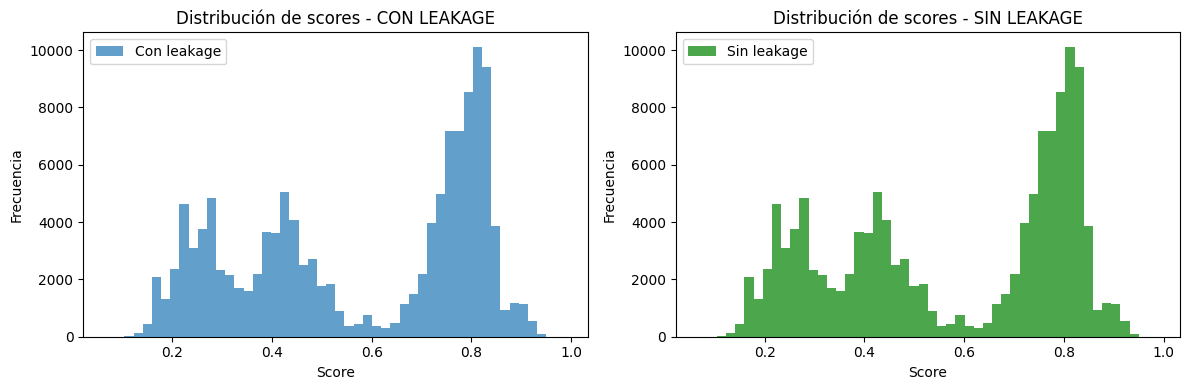

In [10]:
print("=" * 60)
print("RE-ENTRENAMIENTO SIN FEATURES CON LEAKAGE")
print("=" * 60)

# 1. Re-cargar y transformar
fb_clean = FeatureBuilder(CFG).fit(data_train)
fe_clean = fb_clean.transform(data_train)
X_clean, y_clean, meta_clean = fe_clean.X, fe_clean.y, fe_clean.meta

print(f"\n✓ Features eliminadas. Nuevas dimensiones: {X_clean.shape}")
print(f"✓ Features restantes ({len(X_clean.columns)}):")
print(sorted(X_clean.columns.tolist()))

# 2. Verificar que se eliminaron las features con leakage
LEAKY_CHECK = {'lifespan_days', 'days_since_last', 'IsActive', 'accountLevel', 'userTypeIdentifier'}
remaining_leaky = LEAKY_CHECK.intersection(set(X_clean.columns))
if remaining_leaky:
    print(f"\n❌ ERROR: Features con leakage aún presentes: {remaining_leaky}")
else:
    print(f"\n✓ CONFIRMADO: Todas las features con leakage eliminadas")

# 3. Re-entrenar modelo
print("\n" + "=" * 60)
print("ENTRENANDO MODELO LIMPIO...")
print("=" * 60)

time_order_clean = pd.to_datetime(data_train[CFG.signup_date_col], errors="coerce").values
m_w30_clean = Activation30Model(CFG).fit_cv(X_clean, y_clean, time_order_clean)

print("\n=== METRICAS TRAIN (OOF) - MODELO LIMPIO ===")
for k, v in m_w30_clean.metrics_.items():
    print(f"  {k}: {v:.4f}")

# 4. Evaluar en holdout
fe_holdout_clean = fb_clean.transform(data_holdout)
X_holdout_clean, y_holdout_clean = fe_holdout_clean.X, fe_holdout_clean.y
score_holdout_clean = m_w30_clean.predict_proba(X_holdout_clean)

holdout_metrics_clean = {
    "Holdout_AP": average_precision_score(y_holdout_clean, score_holdout_clean),
    "Holdout_AUC": roc_auc_score(y_holdout_clean, score_holdout_clean),
    "Holdout_Brier": brier_score_loss(y_holdout_clean, score_holdout_clean),
    **{f"Holdout_Lift@{int(fr*100)}%": lift_at_k(y_holdout_clean, score_holdout_clean, fr) 
       for fr in CFG.lift_fracs}
}

print("\n=== METRICAS HOLDOUT - MODELO LIMPIO ===")
for k, v in holdout_metrics_clean.items():
    print(f"  {k}: {v:.4f}")

# 5. Comparación antes/después
print("\n" + "=" * 60)
print("COMPARACIÓN: MODELO CON LEAKAGE vs MODELO LIMPIO")
print("=" * 60)
print(f"Train OOF AUC:    {m_w30.metrics_['OOF_AUC']:.4f} → {m_w30_clean.metrics_['OOF_AUC']:.4f}")
print(f"Holdout AUC:      {holdout_metrics['Holdout_AUC']:.4f} → {holdout_metrics_clean['Holdout_AUC']:.4f}")
print(f"Holdout Lift@10%: {holdout_metrics['Holdout_Lift@10%']:.4f} → {holdout_metrics_clean['Holdout_Lift@10%']:.4f}")

# 6. Distribución de scores
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(score_holdout, bins=50, alpha=0.7, label='Con leakage')
plt.xlabel('Score'); plt.ylabel('Frecuencia')
plt.title('Distribución de scores - CON LEAKAGE')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(score_holdout_clean, bins=50, alpha=0.7, label='Sin leakage', color='green')
plt.xlabel('Score'); plt.ylabel('Frecuencia')
plt.title('Distribución de scores - SIN LEAKAGE')
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
# DIAGNÓSTICO DE LEAKAGE
print("Columnas en X:")
print(sorted(X_train.columns.tolist()))

Columnas en X:
['IsActive', 'accountLevel', 'age_years', 'birth_bucket', 'card_linked_before_signup', 'card_linked_lag_days', 'channel_detail_code', 'gender_bin', 'has_premia', 'is_holiday_mx', 'near_payday_15', 'near_payday_1st', 'near_payday_any', 'near_payday_eom', 'signup_daypart', 'signup_dow', 'signup_month', 'signup_week', 'state_AG', 'state_BC', 'state_BS', 'state_CH', 'state_CL', 'state_CM', 'state_CO', 'state_CS', 'state_DF', 'state_DG', 'state_EM', 'state_GR', 'state_GT', 'state_HG', 'state_JA', 'state_MI', 'state_MO', 'state_NA', 'state_NL', 'state_OA', 'state_OT', 'state_PU', 'state_QR', 'state_QT', 'state_SI', 'state_SL', 'state_SO', 'state_TB', 'state_TL', 'state_TM', 'state_VE', 'state_YU', 'state_ZA', 'userTypeIdentifier', 'user_type_tri']


In [12]:
# DIAGNÓSTICO: Correlación con label
print("=== CORRELACIÓN CON LABEL (Top 15) ===")
corr = pd.DataFrame({
    'feature': X_train.columns,
    'corr_with_label': [np.corrcoef(X_train[col].fillna(-999), y_train)[0,1] 
                        for col in X_train.columns]
})
corr['abs_corr'] = corr['corr_with_label'].abs()
corr_sorted = corr.sort_values('abs_corr', ascending=False).head(15)
display(corr_sorted)

# Features sospechosas con correlación > 0.5 son leakage
high_corr = corr_sorted[corr_sorted['abs_corr'] > 0.5]['feature'].tolist()
if high_corr:
    print(f"\n⚠️  LEAKAGE DETECTADO en: {high_corr}")

=== CORRELACIÓN CON LABEL (Top 15) ===


,feature,corr_with_label,abs_corr
0,userTypeIdentifier,0.391225,0.391225
5,user_type_tri,-0.391225,0.391225
51,card_linked_before_signup,0.227903,0.227903
52,card_linked_lag_days,0.227402,0.227402
6,channel_detail_code,0.095712,0.095712
38,state_OT,-0.084428,0.084428
1,accountLevel,0.083992,0.083992
28,state_EM,0.061552,0.061552
8,age_years,-0.054770,0.054770
4,gender_bin,0.050884,0.050884


In [16]:
# === PR & ROC (W30) ===
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, average_precision_score, roc_auc_score

y_true = y
y_score = m_w30.oof_pred_ if getattr(m_w30, "oof_pred_", None) is not None else score_w30_all

prec, rec, thr = precision_recall_curve(y_true, y_score)
fpr, tpr, thr_roc = roc_curve(y_true, y_score)
ap = average_precision_score(y_true, y_score)
auc = roc_auc_score(y_true, y_score)

plt.figure(figsize=(5,5))
plt.plot(rec, prec, label=f"AP={ap:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision–Recall (W30)")
plt.legend(); plt.show()

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC (W30)")
plt.legend(); plt.show()


NameError: name 'y' is not defined

In [ ]:
# === Reliability (W30) ===
from sklearn.calibration import calibration_curve
import pandas as pd

frac_pos, mean_pred = calibration_curve(y_true, y_score, n_bins=20, strategy="quantile")

plt.figure(figsize=(5,5))
plt.plot(mean_pred, frac_pos, marker="o", label="Modelo")
plt.plot([0,1],[0,1], linestyle="--", label="Ideal")
plt.xlabel("Predicho"); plt.ylabel("Empírico")
plt.title("Reliability – W30"); plt.legend(); plt.show()

rel_df = pd.DataFrame({"mean_pred":mean_pred, "frac_pos":frac_pos})
display(rel_df.head(10))


In [ ]:
# === Gains & Lift + Budget curves (W30) ===
import numpy as np, matplotlib.pyplot as plt

def _sort_by_score(y_true, y_score):
    idx = np.argsort(-y_score)
    return y_true[idx], y_score[idx]

def plot_gains_lift(y_true, y_score):
    yt, ys = _sort_by_score(y_true, y_score)
    cum_positives = np.cumsum(yt)
    total_pos = yt.sum()
    n = len(yt)
    xs = np.arange(1, n+1)
    cum_perc = cum_positives / max(1, total_pos)
    pop_perc = xs / n

    # Gains
    plt.figure(figsize=(6,4))
    plt.plot(pop_perc, cum_perc, label="Gains")
    plt.plot([0,1],[0,1], linestyle="--", label="Base")
    plt.xlabel("% Población"); plt.ylabel("% Positivos capturados")
    plt.title("Cumulative Gains – W30")
    plt.legend(); plt.show()

    # Lift
    lift = cum_perc / np.maximum(pop_perc, 1e-9)
    plt.figure(figsize=(6,4))
    plt.plot(pop_perc, lift, label="Lift")
    plt.xlabel("% Población"); plt.ylabel("Lift vs base")
    plt.title("Cumulative Lift – W30")
    plt.legend(); plt.show()

def plot_budget_curves(y_true, y_score, steps=20):
    budgets = np.linspace(0.01, 0.2, steps)  # 1%..20% demo
    recalls, precisions = [], []
    n = len(y_true)
    order = np.argsort(-y_score)
    y_sorted = y_true[order]
    for b in budgets:
        k = max(1, int(n*b))
        tp = y_sorted[:k].sum()
        recalls.append(tp / max(1, y_true.sum()))
        precisions.append(tp / k)

    plt.figure(figsize=(6,4))
    plt.plot(budgets, recalls, marker="o")
    plt.xlabel("Budget (top frac)"); plt.ylabel("Recall@budget")
    plt.title("Recall vs Budget – W30"); plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(budgets, precisions, marker="o")
    plt.xlabel("Budget (top frac)"); plt.ylabel("Precision@budget")
    plt.title("Precision vs Budget – W30"); plt.show()

plot_gains_lift(y_true, y_score)
plot_budget_curves(y_true, y_score, steps=20)


In [ ]:
# === Hist de score global y por canal ===
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,4))
plt.hist(y_score, bins=40)
plt.xlabel("score_w30"); plt.ylabel("freq")
plt.title("Distribución score W30 (global)")
plt.show()

# Por canal (top 4 + otros)
top_channels = meta["channelDetail"].value_counts().head(4).index.tolist()
grp = meta["channelDetail"].where(meta["channelDetail"].isin(top_channels), "OTRO")
for ch in top_channels + ["OTRO"]:
    mask = (grp==ch).values
    if mask.sum()==0: 
        continue
    plt.figure(figsize=(6,4))
    plt.hist(y_score[mask], bins=40)
    plt.xlabel("score_w30"); plt.ylabel("freq")
    plt.title(f"Distribución score W30 – canal={ch}")
    plt.show()


In [ ]:
# === Fairness plots (DP & EO por grupos) ===
import pandas as pd, matplotlib.pyplot as plt
from fairlearn.metrics import MetricFrame

budget = 0.10
k = max(1, int(len(y_true)*budget))
cut = np.partition(-y_score, k-1)[k-1]
y_pred_bin = (y_score >= cut).astype(int)

def fairness_bars(y_true, y_pred, sensitive: pd.Series, title: str):
    mf = MetricFrame(
        metrics={"selection_rate": lambda yt, yp: np.mean(yp),
                 "tpr": lambda yt, yp: ((yp==1)&(yt==1)).sum()/max(1,(yt==1).sum()),
                 "fpr": lambda yt, yp: ((yp==1)&(yt==0)).sum()/max(1,(yt==0).sum())},
        y_true=y_true, y_pred=y_pred, sensitive_features=sensitive
    )
    df = mf.by_group
    for col in ["selection_rate","tpr","fpr"]:
        plt.figure(figsize=(7,4))
        df[col].sort_values(ascending=False).plot(kind="bar")
        plt.title(f"{title} – {col}")
        plt.ylabel(col); plt.tight_layout(); plt.show()
    return df

print("== Fairness por género ==")
df_fair_gender = fairness_bars(y_true, y_pred_bin, meta["gender"], "Género")

print("== Fairness por canal ==")
df_fair_channel = fairness_bars(y_true, y_pred_bin, meta["channelDetail"], "Canal")

print("== Fairness por estado (Top10 + OT) ==")
top_states = meta["state_abbr"].value_counts().head(10).index.tolist()
state10 = meta["state_abbr"].where(meta["state_abbr"].isin(top_states), "OT")
df_fair_state = fairness_bars(y_true, y_pred_bin, state10, "Estado")


In [ ]:
# === PSI score entre 1H vs 2H (orden temporal por signup_date) ===
import numpy as np, matplotlib.pyplot as plt

order = np.argsort(time_order)
mid = len(order)//2
a = y_score[order[:mid]]
b = y_score[order[mid:]]

def psi(a, b, bins=10):
    eps = 1e-9
    qs = np.quantile(a, np.linspace(0,1,bins+1))
    qs[0] -= 1e-6; qs[-1] += 1e-6
    ac,_ = np.histogram(a, bins=qs); bc,_ = np.histogram(b, bins=qs)
    ar = ac / max(1, ac.sum()); br = bc / max(1, bc.sum())
    return float(np.sum((br-ar)*np.log((br+eps)/(ar+eps))))

v = psi(a, b, bins=10)
plt.figure(figsize=(5,3))
plt.bar(["PSI(score)"], [v])
plt.title("PSI 1H vs 2H (score W30)"); plt.ylim(0, max(0.35, v*1.3))
plt.show()
print(f"PSI(score)={v:.4f}  (<=0.1 estable, 0.1–0.2 leve, 0.2–0.3 moderado, >0.3 alto)")


In [ ]:
# === Permutation Importance (último fold) ===
from sklearn.model_selection import TimeSeriesSplit
from sklearn.inspection import permutation_importance
import pandas as pd, numpy as np, matplotlib.pyplot as plt

# reconstruimos el último fold para una vista honesta
order = np.argsort(time_order)
X_ord = X.iloc[order].reset_index(drop=True)
y_ord = y[order]
tss = TimeSeriesSplit(n_splits=CFG.n_splits)
folds = list(tss.split(X_ord))
tr, va = folds[-1]
Xva, yva = X_ord.iloc[va], y_ord[va]

# tomamos el último modelo guardado (alineado al último fold)
mdl = m_w30.model_folds_[-1]
iso = m_w30.iso_folds_[-1]

def scorer(model, Xb, yb):
    p = iso.transform(model.predict_proba(Xb)[:,1])
    return average_precision_score(yb, p)

pi = permutation_importance(mdl, Xva, yva, scoring=None, n_repeats=5, random_state=RNG_SEED)
imp = pd.Series(pi.importances_mean, index=Xva.columns).sort_values(ascending=False).head(25)

plt.figure(figsize=(7,6))
imp[::-1].plot(kind="barh")
plt.title("Permutation Importance (AP) – top 25"); plt.tight_layout(); plt.show()

display(imp.to_frame("importance").head(25))


In [ ]:
# === Confusion matrix (multiclase 0/1/2) en activados con etiqueta disponible ===
from sklearn.metrics import confusion_matrix
import numpy as np, matplotlib.pyplot as plt

mask_eval = (data[CFG.label_col]==1) & data["first_tx_type"].notna()
y_tx_true = data.loc[mask_eval, "first_tx_type"].map(
    lambda v: 0 if v in PHYSICAL_TX else (1 if v in DIGITAL_TX else 2)
).astype(int).values

proba_eval = proba_tx_all[mask_eval.values]
y_tx_pred = np.argmax(proba_eval, axis=1)

cm = confusion_matrix(y_tx_true, y_tx_pred, labels=[0,1,2], normalize="true")

plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion matrix – Tipo de transacción")
plt.xlabel("Predicho"); plt.ylabel("Real")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, f"{cm[i,j]:.2f}", ha="center", va="center")
plt.xticks([0,1,2], ["FÍSICAS","DIGITALES","OTRAS"])
plt.yticks([0,1,2], ["FÍSICAS","DIGITALES","OTRAS"])
plt.colorbar(); plt.tight_layout(); plt.show()


In [ ]:
# === Mix recomendado por budget (W30 top-X%) ===
import pandas as pd, numpy as np, matplotlib.pyplot as plt

df = preds_w30_tx.copy()
for budget in [0.01, 0.02, 0.05, 0.10]:
    k = max(1, int(len(df)*budget))
    topk = df.nlargest(k, "score_w30")
    mix = topk["tx_type_reco_name"].value_counts(normalize=True).sort_index()
    plt.figure(figsize=(5,3))
    mix.plot(kind="bar")
    plt.title(f"Mix tx recomendada en top {int(budget*100)}% (n={k})")
    plt.ylabel("proporción"); plt.tight_layout(); plt.show()


In [ ]:
# === Reliability por canal (top 4 + OTRO) ===
from sklearn.calibration import calibration_curve

top_channels = meta["channelDetail"].value_counts().head(4).index.tolist()
grp = meta["channelDetail"].where(meta["channelDetail"].isin(top_channels), "OTRO")

for ch in top_channels + ["OTRO"]:
    mask = (grp==ch).values
    if mask.sum()<1000:
        continue
    frac_pos, mean_pred = calibration_curve(y_true[mask], y_score[mask], n_bins=10, strategy="quantile")
    plt.figure(figsize=(4,4))
    plt.plot(mean_pred, frac_pos, marker="o", label=ch)
    plt.plot([0,1],[0,1], linestyle="--")
    plt.xlabel("Predicho"); plt.ylabel("Empírico")
    plt.title(f"Reliability – canal={ch}")
    plt.legend(); plt.show()
